In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/Colab Notebooks/northstar_dataset/"

drivers = pd.read_csv(base_path + "drivers.csv")
vehicles = pd.read_csv(base_path + "vehicles.csv")
hubs = pd.read_csv(base_path + "hubs.csv")
incidents = pd.read_csv(base_path + "incidents.csv")
customers = pd.read_csv(base_path + "customers.csv")
app_events = pd.read_csv(base_path + "app_events.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
orders = pd.read_csv(base_path + "orders.csv")


# Data Cleaning & Transformation

### 1. Merging Datasets
The `orders`, `deliveries`, and `customers` tables are merged to create a master dataframe. This helps us see which customer placed which order and who delivered it.

In [ ]:
# Merge Orders with Customers
master_df = pd.merge(orders, customers, on='customer_id', how='left')

# Merge the result with Deliveries
# Note: One order might have one delivery
master_df = pd.merge(master_df, deliveries, on='order_id', how='left')

print("Master DataFrame Shape:", master_df.shape)
display(master_df.head())

Master DataFrame Shape: (1250, 31)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53


### 2. Standardizing Formats
Inconsistent casing (e.g., 'North' vs 'north') can cause issues during analysis. We will convert zone related columns to lowercase and ensure date columns are actual datetime objects.

In [ ]:
# Standardize text to lowercase to avoid duplicates like 'North' and 'north'
master_df['home_zone'] = master_df['home_zone'].str.lower()
master_df['pickup_zone'] = master_df['pickup_zone'].str.lower()
master_df['dropoff_zone'] = master_df['dropoff_zone'].str.lower()
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.lower()

# Further standardize 'ctr' to 'central' across relevant zone columns
master_df['home_zone'] = master_df['home_zone'].replace('ctr', 'central')
master_df['pickup_zone'] = master_df['pickup_zone'].replace('ctr', 'central')
master_df['dropoff_zone'] = master_df['dropoff_zone'].replace('ctr', 'central')
vehicles['assigned_zone'] = vehicles['assigned_zone'].replace('ctr', 'central')

# Convert date strings to datetime objects for calculation
master_df['order_created_at'] = pd.to_datetime(master_df['order_created_at'])
master_df['signup_date'] = pd.to_datetime(master_df['signup_date'])

Standardization complete.


### 3. Detecting Contradictions and Missing Links

In [ ]:
# Identify missing links: Orders without customer details
missing_customers = master_df[master_df['customer_id'].isnull()]
print(f"Orders with missing customer links: {len(missing_customers)}")

# Detect contradictions: Delivery distance cannot be negative
contradictions = master_df[master_df['route_distance_km'] < 0]
print(f"Contradictory data (negative distance): {len(contradictions)}")

# Identify missing links: Orders without deliveries
orders_without_deliveries = master_df[master_df['delivery_id'].isnull()].drop_duplicates(subset=['order_id'])
print(f"Orders without delivery links: {len(orders_without_deliveries)}")

# Identify missing links: Deliveries without orders
# Perform a left merge from 'deliveries' to 'orders' to find deliveries that don't have a matching order
deliveries_without_orders = pd.merge(deliveries, orders, on='order_id', how='left', indicator=True)
deliveries_without_orders = deliveries_without_orders[deliveries_without_orders['_merge'] == 'left_only']
print(f"Deliveries without order links: {len(deliveries_without_orders)}")

Orders with missing customer links: 0
Contradictory data (negative distance): 0
Orders without delivery links: 300
Deliveries without order links: 0


### 4. Cleaning and Transforming
Handling missing values and transforming the merged dataset

In [ ]:
# Fill missing values in categorical columns with 'Unknown'
master_df['service_type'] = master_df['service_type'].fillna('Unknown')

# Deriving a field: Extract hour from order creation
# Created to transform the high precision timestamp to categorical value
master_df['order_hour'] = master_df['order_created_at'].dt.hour

# Display cleaned summary
print("Cleaning and transformation complete.")
display(master_df[['order_id', 'customer_id', 'home_zone', 'order_hour']].head())

Cleaning and transformation complete.


,order_id,customer_id,home_zone,order_hour
0,O00001,C0292,south,14
1,O00002,C0459,west,22
2,O00003,C0161,north,14
3,O00004,C0520,north,17
4,O00005,C0558,south,19


### 5. Processing All Remaining Tables
Applying similar cleaning steps (standardizing text, fixing dates, and checking for missing links) to the `drivers`, `vehicles`, `hubs`, `incidents`, `app_events`, and `complaints` tables.

In [ ]:
# 1. Standardize Drivers and Vehicles
drivers['base_zone'] = drivers['base_zone'].str.lower()
vehicles['vehicle_type'] = vehicles['vehicle_type'].str.lower()
vehicles['commission_date'] = pd.to_datetime(vehicles['commission_date'])

# 2. Clean Incidents and Complaints
incidents['reported_at'] = pd.to_datetime(incidents['reported_at'])
complaints['severity'] = complaints['severity'].fillna('Medium')

# 3. Clean App Events
app_events['event_timestamp'] = pd.to_datetime(app_events['event_timestamp'])

# 4. Check for 'Missing Links' in Incidents
# See if any incident refers to a delivery_id that doesn't exist in our deliveries table
missing_delivery_links = incidents[~incidents['delivery_id'].isin(deliveries['delivery_id'])]

print(f"Incidents with missing delivery links: {len(missing_delivery_links)}")

# data preview
print("Drivers Preview:")
display(drivers.head(3))

print("\nVehicles Preview:")
display(vehicles.head(3))

Incidents with missing delivery links: 0
All tables have been basic-cleaned and standardized.


### 6. Adding Derived Fields
Deriving fields for performance metrics like delays, speeds, and failure flags to help identify operational bottlenecks.

In [ ]:
# 1. Delay & Time-Based Fields
# Calculate delay in minutes: difference between actual completion and promised dispatch (using dispatch_time as a baseline)
master_df['delivery_completed_at'] = pd.to_datetime(master_df['delivery_completed_at'])
master_df['dispatch_time'] = pd.to_datetime(master_df['dispatch_time'])

# Delay in minutes (if actual completion exists)
master_df['delay_minutes'] = (master_df['delivery_completed_at'] - master_df['dispatch_time']).dt.total_seconds() / 60

# 2. Performance & Reliability Fields
# Calculate average speed (km/h)
# Assuming the delivery took the time between dispatch and completion
duration_hours = (master_df['delivery_completed_at'] - master_df['dispatch_time']).dt.total_seconds() / 3600
master_df['avg_speed_kmph'] = master_df['route_distance_km'] / duration_hours

# 3. Failure & Exception Flags
# A simple flag if there was a manual override or if completion proof is missing
master_df['failure_flag'] = ((master_df['manual_route_override_count'] > 0) | (master_df['proof_of_completion_missing'] == 1.0)).astype(int)

# 4. Customer & Complaint Links
# Create a flag if a customer has ever lodged a complaint
complaint_customers = complaints['customer_id'].unique()
master_df['has_complaint_history'] = master_df['customer_id'].isin(complaint_customers)

print("Derived fields added successfully.")
display(master_df[['order_id', 'delay_minutes', 'avg_speed_kmph', 'failure_flag', 'has_complaint_history']].head())

Derived fields added successfully.


,order_id,delay_minutes,avg_speed_kmph,failure_flag,has_complaint_history
0,O00001,143.936203,11.109088,1,True
1,O00002,NaN,NaN,0,True
2,O00003,531.660745,1.471615,1,True
3,O00004,-66.000000,-9.400000,1,False
4,O00005,702.000785,1.368375,1,True


### 7. Final Dataset Integration
We will perform the final merges to include Driver details, Vehicle specifications, and Hub information into our master dataframe.

By merging the data we can address complex cross table questions.

In [ ]:
# Merge with Drivers
master_df = pd.merge(master_df, drivers, on='driver_id', how='left')

# Merge with Vehicles
master_df = pd.merge(master_df, vehicles, on='vehicle_id', how='left')

# Merge with Hubs
# Hubs are linked via 'hub_id'
master_df = pd.merge(master_df, hubs, on='hub_id', how='left')

print("Final Integrated Master DataFrame Shape:", master_df.shape)
display(master_df[['order_id', 'driver_id', 'years_experience', 'vehicle_type', 'hub_name']].head())

Final Integrated Master DataFrame Shape: (1250, 54)


,order_id,driver_id,years_experience,vehicle_type,hub_name
0,O00001,D047,7.0,hybrid,North Exchange
1,O00002,NaN,NaN,NaN,NaN
2,O00003,D041,3.0,cargovan,South Link
3,O00004,D138,11.0,diesel,South Link
4,O00005,D054,3.0,hybrid,East Dock


# Data Analysis

### Business Impact: Performance Analysis

The **Performance Analysis** section provides a high-level overview of the delivery operations. By tracking:

*   **Total Journeys**: Gives a count of all delivery attempts, essential for understanding operational scale.
*   **Total Successful Journeys**: Indicates the overall success rate, directly impacting customer satisfaction and revenue.
*   **Total Failed Journeys**: Highlights the number of deliveries that encountered significant issues, which can point to systemic problems.
*   **Average Delay**: Calculates the average lateness of deliveries, a critical metric for customer experience and operational efficiency.
*   **Average Order Value (Cost)**: Provides insight into the typical revenue generated per order, helping in financial planning and assessing the value of individual transactions.

**Business Problem Solved**: This analysis helps management quickly grasp the overall perfromance of the delivery system. It allows them to identify if operations are reaching their goals, if success rates are meeting targets, and if delays or failures are becoming a significant problem, all of which directly affect customer retention and profitability. For example, a high average delay might prompt an investigation into routing algorithms or driver availability.

## Performance Analysis

In [ ]:
# Total Journeys
total_journeys = len(master_df)
print(f"Total Journeys: {total_journeys}")

Total Journeys: 1250


In [ ]:
# Total Successful Journeys
successful_journeys = master_df[master_df['delivery_status'] == 'Completed'].shape[0]
print(f"Total Successful Journeys: {successful_journeys}")

Total Successful Journeys: 0


In [ ]:
# Total Failed Journeys
failed_journeys = master_df[master_df['failure_flag'] == 1].shape[0]
print(f"Total Failed Journeys: {failed_journeys}")

Total Failed Journeys: 580


In [ ]:
# Average Delay
average_delay = master_df['delay_minutes'].mean()
print(f"Average Delay (minutes): {average_delay:.2f}")

Average Delay (minutes): 572.73


In [ ]:
# Average Cost
average_cost = master_df['order_value'].mean()
print(f"Average Order Value (Cost): {average_cost:.2f}")

Average Order Value (Cost): 91.05


## Delay Analysis

### Business Impact: Delay Analysis

**Delay Analysis** dives deeper into the causes and patterns of delivery delays:

*   **Average Delay per Route (pickup and dropoff zone)**: Pinpoints specific routes that consistently experience longer delays. This is crucial for optimizing route planning, identifying high traffic routes, or re-evaluating expected delivery times for certain locations.
*   **Average Delay per Hub**: Identifies which operational hubs might be underperforming, either due to resource constraints (too few drivers/vehicles), inefficient processing, or logistical challenges unique to that hub's location.
*   **Percentage of Delayed Journeys**: Provides a clear metric on how widespread the delay issue is across all deliveries. A high percentage indicates a systemic problem rather than isolated incidents.

**Business Problem Solved**: This section directly addresses the challenge of late deliveries, a major source of customer dissatisfaction. By identifying specific problematic routes and hubs, the business can take targeted actions such as adjusting staffing, rerouting deliveries, investing in infrastructure for certain hubs, or communicating more realistic delivery estimates to customers. Reducing delays can significantly improve customer loyalty and company reputation.

In [ ]:
# Average Delay per Route (pickup and dropoff zone)
average_delay_per_route = master_df.groupby(['pickup_zone', 'dropoff_zone'])['delay_minutes'].mean().reset_index()
print("Average Delay per Route (minutes):")
display(average_delay_per_route.head())

Average Delay per Route (minutes):


,pickup_zone,dropoff_zone,delay_minutes
0,airport,airport,622.054212
1,airport,central,607.477353
2,airport,east,480.409165
3,airport,north,502.451891
4,airport,riverside,534.854371


In [ ]:
# Average Delay per Hub
average_delay_per_hub = master_df.groupby('hub_name')['delay_minutes'].mean().reset_index()
print("Average Delay per Hub (minutes):")
display(average_delay_per_hub.head())

Average Delay per Hub (minutes):


,hub_name,delay_minutes
0,Airport Hub,562.758006
1,Central Core,654.248030
2,East Dock,459.414852
3,Midtown Relay,589.150707
4,North Exchange,562.902086


In [ ]:
# Percentage of Delayed Journeys
total_journeys = len(master_df)
delayed_journeys = master_df[master_df['delay_minutes'] > 0].shape[0]
percentage_delayed_journeys = (delayed_journeys / total_journeys) * 100
print(f"Percentage of Delayed Journeys: {percentage_delayed_journeys:.2f}%")

Percentage of Delayed Journeys: 69.36%


## Failure Analysis

### Business Impact: Failure Analysis

**Failure Analysis** examines the root causes and locations of delivery failures and exceptions:

*   **Failure Rate per Route (pickup and dropoff zone)**: Highlights routes where deliveries are more likely to fail entirely. This could be due to difficult delivery locations, high-crime areas, or issues with specific customers.
*   **Failure Rate per Hub**: Similar to delay analysis, this identifies hubs with a higher propensity for failed deliveries, suggesting potential operational inefficiencies, scarce resources, bad infrastructure or local challenges.
*   **Average Manual Route Overrides per Journey**: Measures the frequency of situations where drivers deviate from planned routes. A high number suggests that the automated routing system might be inadequate, drivers are facing unforeseen obstacles, or there's a lack of proper training on following routes.
*   **Analysis of orders without deliveries, including cancellation events and complaints**: Provides insights into why some orders never make it to delivery. This can uncover issues like frequent customer cancellations due to long wait times, problems with order processing, or even fraudulent orders.

**Business Problem Solved**: This analysis is critical for improving service reliability and reducing operational costs associated with failed deliveries (re-delivery attempts, refunds, customer service). Pinpointing high-failure routes or hubs allows for focused interventions, such as improving route optimization, enhancing driver support, addressing specific customer communication gaps, or investigating patterns of cancellations to improve service quality and retention.

In [ ]:
# Failure Rate per Route (pickup and dropoff zone)
failure_rate_per_route = master_df.groupby(['pickup_zone', 'dropoff_zone'])['failure_flag'].mean().reset_index()
print("Failure Rate per Route:")
display(failure_rate_per_route.head())

Failure Rate per Route:


,pickup_zone,dropoff_zone,failure_flag
0,airport,airport,0.739130
1,airport,central,0.875000
2,airport,east,0.600000
3,airport,north,0.500000
4,airport,riverside,0.666667


In [ ]:
# Failure Rate per Hub
failure_rate_per_hub = master_df.groupby('hub_name')['failure_flag'].mean().reset_index()
print("Failure Rate per Hub:")
display(failure_rate_per_hub.head())

Failure Rate per Hub:


,hub_name,failure_flag
0,Airport Hub,0.634615
1,Central Core,0.626087
2,East Dock,0.554622
3,Midtown Relay,0.687500
4,North Exchange,0.632353


In [ ]:
# Average Manual Route Overrides per Journey (as a simple measure of exceptions)
average_exceptions_per_journey = master_df['manual_route_override_count'].mean()
print(f"Average Manual Route Overrides per Journey: {average_exceptions_per_journey:.2f}")

Average Manual Route Overrides per Journey: 0.97


In [ ]:
# Orders that dont have deliveries
# Get the IDs of orders without deliveries
missing_delivery_order_ids = orders_without_deliveries['order_id'].unique()

# 1. Check App Events for cancellation signals
cancel_events = app_events[(app_events['order_id'].isin(missing_delivery_order_ids)) &
                           (app_events['event_type'].str.contains('cancel', case=False, na=False))]

# 2. Check Complaints for these orders
related_complaints = complaints[complaints['order_id'].isin(missing_delivery_order_ids)]

# 3. Check for common traits in orders without deliveries (e.g., specific zones or low loyalty scores)
missing_info_summary = orders_without_deliveries.groupby('pickup_zone').size().rename('missing_delivery_count').reset_index()

print(f"Total orders without deliveries: {len(missing_delivery_order_ids)}")
print(f"Orders with 'cancel' events in app_events: {len(cancel_events['order_id'].unique())}")
print(f"Orders with associated complaints: {len(related_complaints['order_id'].unique())}")

print("\nDistribution of missing deliveries by Pickup Zone:")
display(missing_info_summary.sort_values(by='missing_delivery_count', ascending=False))

Total orders without deliveries: 300
Orders with 'cancel' events in app_events: 5
Orders with associated complaints: 76

Distribution of missing deliveries by Pickup Zone:


,pickup_zone,missing_delivery_count
1,central,64
2,east,51
5,south,42
6,west,41
3,north,39
4,riverside,32
0,airport,31


## Cost Analysis

### Business Impact: Cost Analysis

**Cost Analysis** focuses on the financial efficiency of the delivery operations:

*   **Average Cost per Delivery (Order Value)**: While presented as order value, this can be interpreted as the average revenue generated per delivery. In conjunction with actual delivery costs, it helps assess profitability per delivery.
*   **Average Cost per Kilometer**: Provides a metric for transportation efficiency. A high cost per kilometer might indicate inefficient routing, high fuel consumption, or expensive or inadequate vehicle maintenance.
*   **Average Cost per Route (pickup and dropoff zone)**: Identifies which routes are the most expensive to serve. This can be due to long distances, difficult terrain, high traffic, or areas requiring specific vehicles/drivers.

**Business Problem Solved**: This section directly informs financial decision-making and cost optimization strategies. By understanding the cost drivers at a per-delivery, per-kilometer, and per-route level, the business can:
*   Identify and streamline high-cost routes.
*   Adjust pricing for deliveries in expensive zones.
*   Optimize vehicle usage and fuel efficiency.
*   Improve route planning to minimize distance traveled for the same delivery volume.
*   Ultimately, this helps in improving profit margins and ensuring sustainable growth.

In [ ]:
# Cost per delivery (average order value)
# As each row in master_df represents a delivery, the 'order_value' is effectively the cost per delivery.
cost_per_delivery = master_df['order_value'].mean()
print(f"Average Cost per Delivery: ${cost_per_delivery:.2f}")

Average Cost per Delivery: $91.05


In [ ]:
# Cost per mile
# Calculate cost per km for each delivery, handling potential division by zero
master_df['cost_per_km'] = master_df.apply(lambda row: row['order_value'] / row['route_distance_km'] if row['route_distance_km'] > 0 else 0, axis=1)

average_cost_per_km = master_df['cost_per_km'].mean()
print(f"Average Cost per Kilometer: ${average_cost_per_km:.2f}")

Average Cost per Kilometer: $7.52


In [ ]:
# Average cost per route (pickup and dropoff zone)
average_cost_per_route = master_df.groupby(['pickup_zone', 'dropoff_zone'])['order_value'].mean().reset_index()
print("Average Cost per Route (Pickup Zone to Dropoff Zone):")
display(average_cost_per_route.head())

Average Cost per Route (Pickup Zone to Dropoff Zone):


,pickup_zone,dropoff_zone,order_value
0,airport,airport,109.937826
1,airport,central,128.842500
2,airport,east,83.691333
3,airport,north,114.951667
4,airport,riverside,96.480952


# Visualizations

### Business Impact: Top 10 Average Delay per Route

This bar chart visualizes the routes with the highest average delays. By identifying these problematic routes, the business can:

*   **Optimize Routing Algorithms**: Investigate why these specific routes are consistently delayed and adjust routing logic to avoid or mitigate these issues.
*   **Resource Allocation**: Assign more drivers or vehicles to these routes during peak times, or re-evaluate the estimated delivery times.
*   **Customer Communication**: Inform customers in these zones about potential delays, managing expectations and improving satisfaction.
*   **Infrastructure Improvement**: Highlight areas where traffic congestion or poor road conditions might be contributing to delays, potentially informing public works requests or internal logistics changes.

**Business Problem Solved**: This directly tackles customer dissatisfaction due to late deliveries and operational inefficiencies. Pinpointing the problematic routes allows for targeted interventions, leading to improved delivery times and customer loyalty.

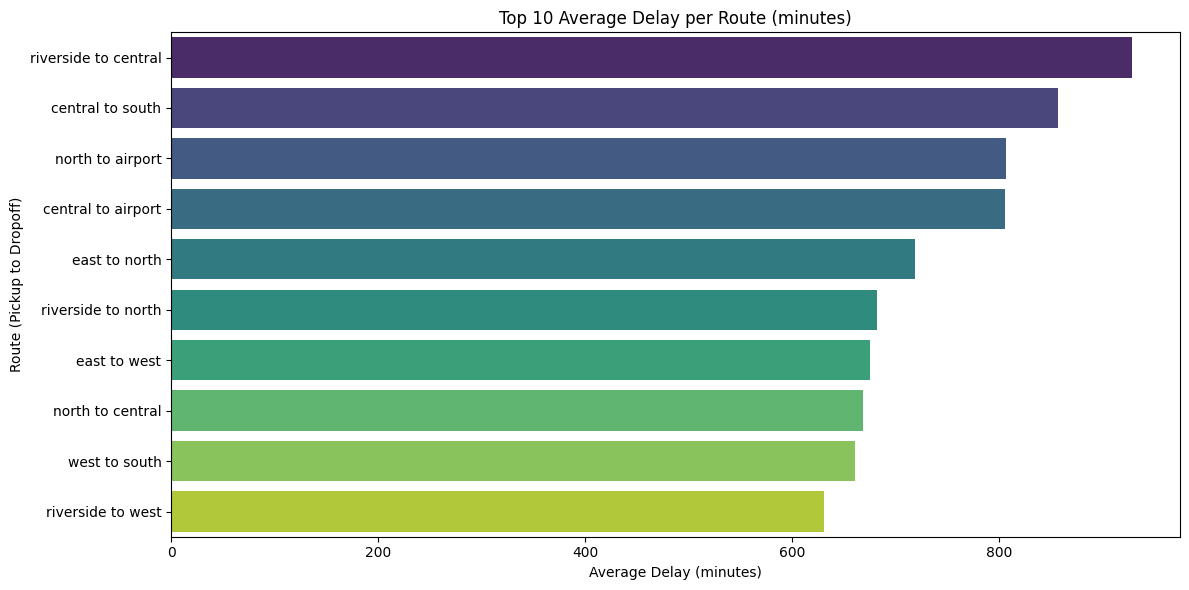

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar chart: average delay per route
# Sort for better visualization and take top 10 routes
top_routes_delay = average_delay_per_route.sort_values(by='delay_minutes', ascending=False).head(10)
top_routes_delay['route_label'] = top_routes_delay['pickup_zone'] + ' to ' + top_routes_delay['dropoff_zone']

plt.figure(figsize=(12, 6))
sns.barplot(x='delay_minutes', y='route_label', data=top_routes_delay, palette='viridis', hue='route_label', legend=False)
plt.title('Top 10 Average Delay per Route (minutes)')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Route (Pickup to Dropoff)')
plt.tight_layout()
plt.show()

### Business Impact: Failure Rate per Hub

This bar chart shows the failure rate for deliveries originating from each hub. This visualization helps the business to:

*   **Identify Underperforming Hubs**: Clearly shows which hubs have high delivery failure rates.
*   **Operational Audits**: Encourages investigations into the identified hubs regarding staffing, training, local challenges, or infrastructure problems.
*   **Risk Mitigation**: Implement specific training programs for drivers in high-failure hubs, or adjust operational procedures.
*   **Strategic Planning**: Informed decisions about hub expansion, consolidation, or resource reallocation based on performance.

**Business Problem Solved**: This addresses the critical issue of failed deliveries, which results in lost revenue, customer frustration, and increased operational costs (re-delivery attempts, refunds). By identifying and improving high-failure hubs, the business can enhance service reliability and reduce overall operational expenditure.

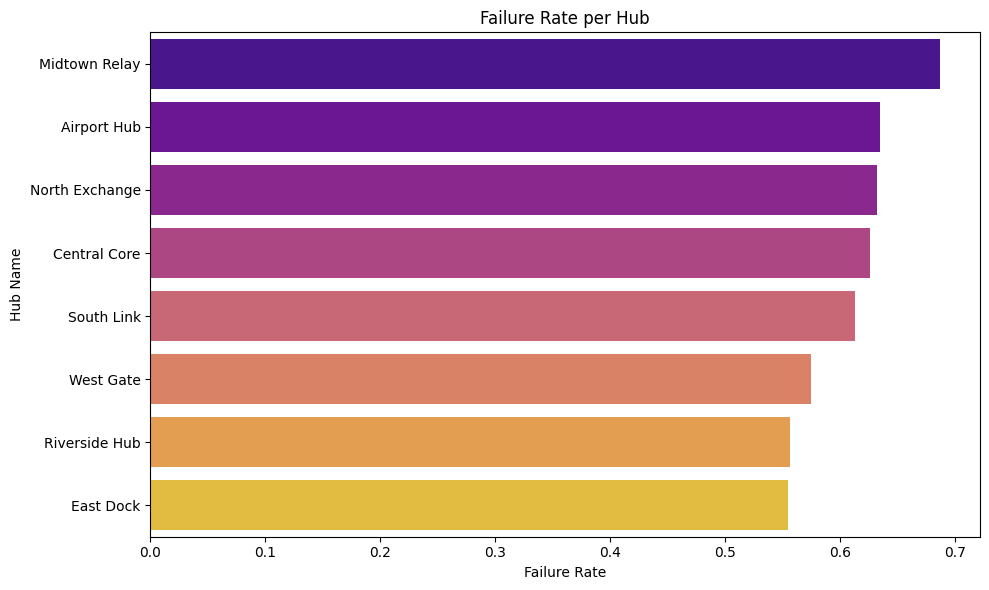

In [ ]:
# 2. Bar chart: failure rate per hub
plt.figure(figsize=(10, 6))
sns.barplot(x='failure_flag', y='hub_name', data=failure_rate_per_hub.sort_values(by='failure_flag', ascending=False), palette='plasma', hue='hub_name', legend=False)
plt.title('Failure Rate per Hub')
plt.xlabel('Failure Rate')
plt.ylabel('Hub Name')
plt.tight_layout()
plt.show()

### Business Impact: Average Delay Over Time

This line chart displays the trend of average daily delays over a period. This visualization is crucial for:

*   **Trend Identification**: Reveals if delays are increasing, decreasing, or fluctuating, helping to identify seasonal patterns, impacts of new policies, or external factors.
*   **Early Warning System**: A sudden spike in average delay can signal a systemic issue (e.g., a major traffic event, system outage, or unexpected surge in orders) that requires immediate attention.
*   **Performance Monitoring**: Allows management to track the effectiveness of initiatives aimed at reducing delays.
*   **Forecasting**: Historical trends can aid in forecasting future delivery performance and setting realistic expectations.

**Business Problem Solved**: This helps in proactive management of delivery operations. By monitoring delay trends, the business can respond quickly to worsening performance, understand the long-term impact of changes, and continuously work towards maintaining optimal delivery times, which directly impacts customer satisfaction and operational reputation.

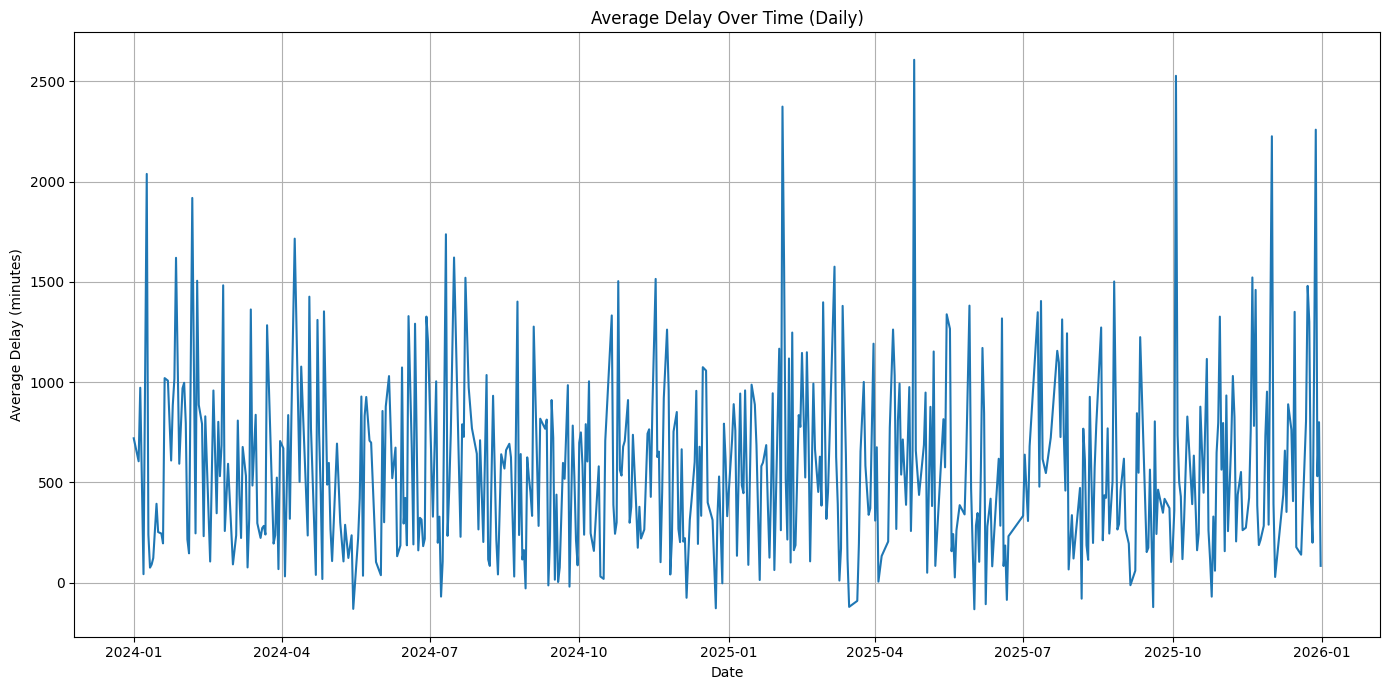

In [ ]:
# 3. Line chart: delays over time
# Aggregate master_df by date for average delay
delays_over_time = master_df.set_index('order_created_at').resample('D')['delay_minutes'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='order_created_at', y='delay_minutes', data=delays_over_time)
plt.title('Average Delay Over Time (Daily)')
plt.xlabel('Date')
plt.ylabel('Average Delay (minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Business Impact: Order Value vs. Delay Minutes (Colored by Failure Flag)

This scatter plot explores the relationship between the value of an order, its delay, and whether it resulted in a failure. This rich visualization helps the business to:

*   **Prioritize High-Value Deliveries**: Identify if high-value orders are also experiencing significant delays or failures, which could lead to substantial financial losses and premium customer dissatisfaction.
*   **Risk Assessment**: Understand if certain combinations of order value and delay are more prone to delivery failure.
*   **Targeted Interventions**: If high-value orders are frequently delayed or failed, the business might implement special handling procedures or offer premium delivery options for them.
*   **Customer Segmentation**: Inform strategies for managing different customer segments based on their order value and the typical delivery experience they receive.

**Business Problem Solved**: This visualization helps the business protect revenue and improve customer experience, especially for its most valuable orders. By understanding the relationship between order value, delay, and failure, the business can prioritize efforts to reduce risks for critical deliveries and optimize overall service quality.

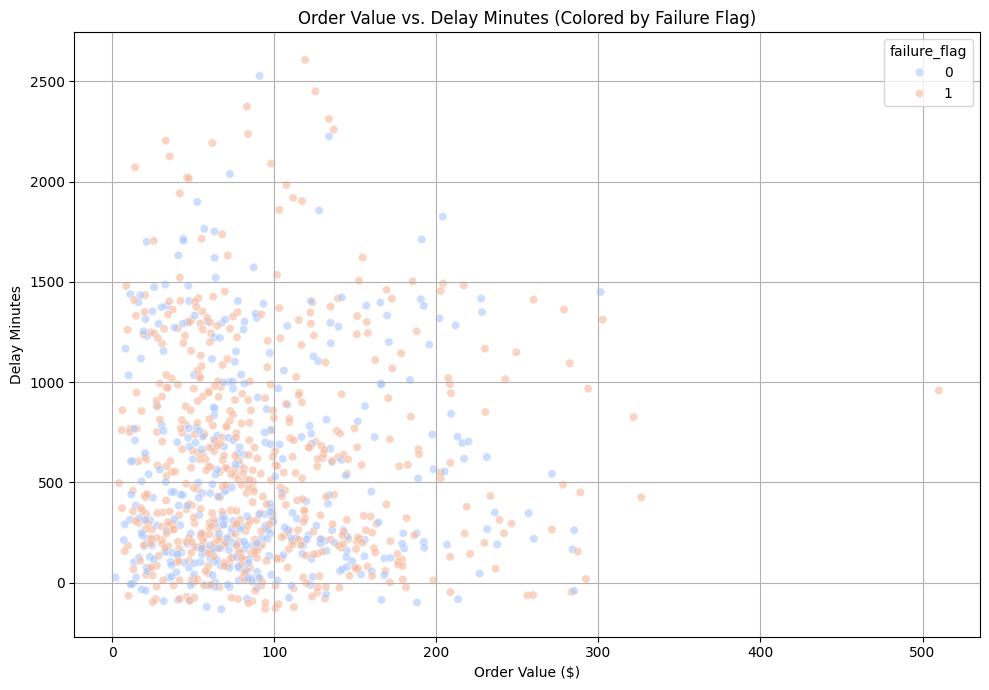

In [ ]:
# 4. Scatter plot: cost vs delay
plt.figure(figsize=(10, 7))
sns.scatterplot(x='order_value', y='delay_minutes', data=master_df, alpha=0.6, hue='failure_flag', palette='coolwarm')
plt.title('Order Value vs. Delay Minutes (Colored by Failure Flag)')
plt.xlabel('Order Value ($)')
plt.ylabel('Delay Minutes')
plt.grid(True)
plt.tight_layout()
plt.show()

# Preparing MongoDB-Ready JSON Documents (Specific Schema)

We will now prepare three sets of JSON documents (`orders_mongo.json`, `complaints_mongo.json`, and `deliveries_mongo.json`) by transforming our flat DataFrames into hierarchical, nested structures suitable for NoSQL storage.

In [ ]:
import json

# --- 1. Preparation: Group nested entities using cleaned DataFrames ---

# Group app events by order_id (using cleaned app_events)
events_by_order = app_events.groupby('order_id').apply(
    lambda x: x.to_dict(orient='records'), include_groups=False
).to_dict()

# Group incidents by delivery_id (using cleaned incidents)
incidents_by_delivery = incidents.groupby('delivery_id').apply(
    lambda x: x.to_dict(orient='records'), include_groups=False
).to_dict()

# Create a lookup for deliveries by order_id to embed as sub-documents
# Using cleaned deliveries
delivery_lookup = deliveries.set_index('order_id').to_dict(orient='index')

# --- 2. Generate orders_mongo.json ---
# Using master_df which contains integrated customer and delivery data
orders_list = []
# We take unique orders from master_df
# Note: master_df has merged columns, we filter to relevant ones or use full cleaned record
for _, order_row in master_df.drop_duplicates(subset=['order_id']).iterrows():
    order_doc = order_row.to_dict()
    order_id = order_doc['order_id']

    # Embed Events
    order_doc['events'] = events_by_order.get(order_id, [])

    # Embed nested Incidents into the delivery part of the document
    # Since master_df already has delivery info, we just need to nest the incidents
    del_id = order_doc.get('delivery_id')
    if pd.notnull(del_id):
        order_doc['incidents'] = incidents_by_delivery.get(del_id, [])
    else:
        order_doc['incidents'] = []

    orders_list.append(order_doc)

with open('orders_mongo.json', 'w') as f:
    json.dump(orders_list, f, indent=4, default=str)

# --- 3. Generate complaints_mongo.json ---
# Using cleaned complaints
complaints_list = complaints.to_dict(orient='records')
with open('complaints_mongo.json', 'w') as f:
    json.dump(complaints_list, f, indent=4, default=str)

# --- 4. Generate deliveries_mongo.json ---
# Using cleaned deliveries
deliveries_list = []
for _, del_row in deliveries.iterrows():
    del_doc = del_row.to_dict()
    del_id = del_doc['delivery_id']

    # Embed Incidents
    del_doc['incidents'] = incidents_by_delivery.get(del_id, [])
    deliveries_list.append(del_doc)

with open('deliveries_mongo.json', 'w') as f:
    json.dump(deliveries_list, f, indent=4, default=str)

print("JSON documents generated using CLEANED data: orders_mongo.json, complaints_mongo.json, deliveries_mongo.json")

JSON documents generated using CLEANED data: orders_mongo.json, complaints_mongo.json, deliveries_mongo.json


### Report Explanation: Preparing Nested JSON for MongoDB
The relational database is not suitable for storing the nested structures present in the database, by using  python and the `pandas` library we can transform flat CSV structures into nested JSON documents. These JSON documents can be stored in MongoDB

We can see that some of the data act as secondary records (like app_events and incidents), and others act like parent records (deliveries and orders). These secondary records are mapped to the parent records and added as sub documents. This is done by using `groupby` and `to_dict(orient='records')` methods to turn the records into lists. This nested data is then stored inside of MongoDB which then eliminates the need for expensive joins.